In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression

from numpy.linalg import qr

In [2]:
def define_data_set_old(num_tasks, T):

    x_dataset = torch.zeros([num_tasks, 4, T]); y_dataset = []; 
    
    #coin flips for ground truth
    context_ = 2*np.random.rand(num_tasks) - 1           #-1 = motion context; +1 = color context
    context = 2*((context_<0.0).astype(int))-1      #-1 = motion context; +1 = color context
    
    color_ = 2*np.random.rand(num_tasks) - 1             #-1 = blue; +1 = red
    color = 2*((color_<0.0).astype(int)) - 1               #-1 = blue; +1 = red
    
    motion_ = 2*np.random.rand(num_tasks) - 1 #0 = left; 1 = right
    motion = 2*((motion_<0.0).astype(int)) - 1 #0 = left; 1 = right

    y_dataset_full = torch.cat((torch.tensor(motion).unsqueeze(1), torch.tensor(color).unsqueeze(1), torch.tensor(context).unsqueeze(1)), dim=1)
    
    for n in range(num_tasks):

        if context[n] == -1:
            y_dataset.append(motion[n])        
        else:
            y_dataset.append(color[n])

        motion_signal = motion_[n] + motion_[n]/10*np.random.randn(T)        
        color_signal = color_[n] + color_[n]/10*np.random.randn(T)        

        motion_signal = 0.2*motion_signal; color_signal = 0.2*color_signal;
        
        x_dataset[n,0,:] = torch.tensor(motion_signal)
        x_dataset[n,1,:] = torch.tensor(color_signal)
        
        if context[n] == -1:
            x_dataset[n,2,:] = torch.tensor([1]*T)
            x_dataset[n,3,:] = torch.tensor([0]*T)
        else:
            x_dataset[n,2,:] = torch.tensor([0]*T)
            x_dataset[n,3,:] = torch.tensor([1]*T)

    y_dataset = torch.tensor(y_dataset)

    return x_dataset, y_dataset, y_dataset_full

In [3]:
def define_data_set(num_tasks, T):
    x_dataset = torch.zeros([num_tasks, 4, T])
    y_dataset = torch.zeros([num_tasks, T])
    
    # ground truth
    context_ = 2*np.random.rand(num_tasks) - 1
    context = 2*((context_<0.0).astype(int)) - 1

    color_ = 2*np.random.rand(num_tasks) - 1
    color = 2*((color_<0.0).astype(int)) - 1

    motion_ = 2*np.random.rand(num_tasks) - 1
    motion = 2*((motion_<0.0).astype(int)) - 1

    y_dataset_full = torch.cat((torch.tensor(motion).unsqueeze(1), torch.tensor(color).unsqueeze(1), torch.tensor(context).unsqueeze(1)), dim=1)

    fix_end = int(0.2 * T)
    stim_end = int(0.8 * T)

    for n in range(num_tasks):
        # target per timestep
        if context[n] == -1:
            y_dataset[n, fix_end:stim_end] = motion[n]
            #y_dataset[n] = motion[n]
        else:
            y_dataset[n, fix_end:stim_end] = color[n]
            #y_dataset[n] = color[n]

        # coherence
        coh = np.random.choice([0.05, 0.1, 0.2])  # slightly stronger
        # baseline noise
        motion_signal = 0.01*np.random.randn(T)
        color_signal  = 0.01*np.random.randn(T)
        # add stimulus
        motion_signal[fix_end:stim_end] += motion_[n] * coh
        color_signal[fix_end:stim_end]  += color_[n]  * coh

        x_dataset[n,0,:] = torch.tensor(motion_signal)
        x_dataset[n,1,:] = torch.tensor(color_signal)

        # context input
        if context[n] == -1:
            x_dataset[n,2,:] = 1.0
            x_dataset[n,3,:] = 0.0
        else:
            x_dataset[n,2,:] = 0.0
            x_dataset[n,3,:] = 1.0

    return x_dataset, y_dataset, y_dataset_full



In [4]:
x_dataset, y_dataset, y_dataset_full = define_data_set_old(10000, 750)
print("training data shapes", x_dataset.shape, y_dataset.shape)
training_dataset = TensorDataset(x_dataset, y_dataset)
training_data = DataLoader(training_dataset, batch_size=50, shuffle=True)

x_dataset2, y_dataset2, y_dataset_full2 = define_data_set_old(1000, 750)
print("training data shapes", x_dataset.shape, y_dataset.shape)
testing_dataset = TensorDataset(x_dataset2, y_dataset2)
testing_data = DataLoader(testing_dataset, batch_size=len(x_dataset2), shuffle=True)


training data shapes torch.Size([10000, 4, 750]) torch.Size([10000])
training data shapes torch.Size([10000, 4, 750]) torch.Size([10000])


In [10]:
class RNN_neuro(nn.Module):
    
     def __init__(self, input_size=4, hidden_size=100, output_size = 1, batchsize = 50, dt=1, **kwargs):
        super().__init__()
         
        self.J_weights = nn.Parameter(1.5*torch.randn(hidden_size, hidden_size)/np.sqrt(hidden_size), requires_grad=True)
        self.nonlinear_fn = nn.Tanh()
    
        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.bias = nn.Parameter(torch.randn(hidden_size), requires_grad = True)

        self.std = 0.1
         
        self.tau = 10;
        self.dt = 1
        self.T = 750

        self.hidden_size = hidden_size
         
     def forward(self, input_):

        input_ = input_.float()
        batchsize = len(input_)
         
        x = torch.zeros(batchsize, self.hidden_size, device=input_.device)
        r = self.nonlinear_fn(x)

        all_x = []; all_r = []; 
        all_z = [];

        for t in range(self.T):
            temp = self.fc_in(input_[:,:,t]) + self.bias
            noise = self.std*torch.randn(batchsize, self.hidden_size) 

            x = x + self.dt/self.tau * (-x + r @ self.J_weights.T + temp + noise)
            r = self.nonlinear_fn(x)
            out = self.fc_out(r)

            all_x.append(x); all_r.append(r); 
            all_z.append(out)

        all_x = torch.stack(all_x, dim=2)
        all_r = torch.stack(all_r, dim=2)
        all_z = torch.stack(all_z, dim=2)
         
        return all_z, all_x, all_r

In [6]:
model = RNN_neuro()
model.float()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()   # Mante uses MSE on final output

In [7]:
def train_model(model, training_data, num_epochs=5, batchsize=50, lr=1e-3):

    epoch_loss_arr = []
    epoch_acc_arr = []
    y_arr = []; X_arr = [];
    z_final_arr = []; r_final_arr = []; x_final_arr = [];
    for epoch in range(num_epochs):

        epoch_loss = 0
        epoch_acc = 0
        epoch_total = 0
        for bid, batch in enumerate(training_data):

            X, y = batch
            batchsize, n_features, T = X.shape
            
            # forward pass
            all_z, all_x, all_r = model(X)
            
            # final output at last time step, shape (batch, 1)
            z_final = all_z[:, 0, - 1]

            optimizer.zero_grad()
            # MSE loss target needs shape (batch,)
            #loss = loss_fn(all_z[:,0,:750], y.float())
            loss = loss_fn(z_final, y.float())
            
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            
            preds = (z_final > 0).long()*2 - 1
            correct = (preds == y).sum().item()
            #correct = (preds == y).sum().item()
            epoch_acc += correct
            epoch_total += batchsize

            epoch_loss_arr.append(loss)
            epoch_acc_arr.append(float(correct)/batchsize)
            X_arr.append(X); y_arr.append(y);

            z_final_arr.append(all_z); x_final_arr.append(all_x); r_final_arr.append(all_r);
            
            print(bid, correct/batchsize)
            
        epoch_acc = epoch_acc / epoch_total
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}%")
        
    z_final_arr = torch.stack(z_final_arr).view(-1, model.T); 
    x_final_arr = torch.stack(x_final_arr).view(-1, model.hidden_size, model.T); 
    r_final_arr = torch.stack(r_final_arr).view(-1, model.hidden_size, model.T); 
    X_arr = torch.stack(X_arr); y_arr = torch.stack(y_arr).flatten()

    print("r_final_arr shapes etc", r_final_arr.shape, x_final_arr.shape, z_final_arr.shape)

    return epoch_loss_arr, epoch_acc_arr, X_arr, y_arr, x_final_arr, r_final_arr, z_final_arr

In [8]:
def test_model(model, testing_data):

    for bid, batch in enumerate(testing_data):

        X, y = batch
        batchsize, n_features, T = X.shape
        print("batchsize", batchsize)

        # forward pass
        all_z, all_x, all_r = model(X)
        
        # final output at last time step, shape (batch, 1)
        z_final = all_z[:, 0, - 1]

        #compute testing loss
        loss = loss_fn(z_final, y.float())


        preds = torch.sign(z_final)
        correct = (preds == y).sum().item()
        accuracy = correct/batchsize

    print(f"Testing loss is {loss.item()} and accuracy {accuracy*100}")
    return X, y, all_r

In [9]:
epoch_loss, epoch_acc, X_arr, y_arr, x_final_arr, r_final_arr, z_final_arr = train_model(model, training_data)

0 0.48
1 0.42
2 0.38
3 0.56
4 0.6
5 0.44
6 0.5
7 0.62
8 0.38
9 0.62
10 0.4
11 0.66
12 0.4
13 0.56
14 0.44
15 0.56
16 0.48
17 0.5
18 0.52
19 0.64
20 0.7
21 0.62
22 0.5
23 0.46
24 0.58
25 0.5
26 0.6
27 0.66
28 0.76
29 0.64
30 0.68
31 0.6
32 0.78
33 0.7
34 0.84
35 0.8
36 0.78
37 0.66
38 0.68
39 0.68
40 0.62
41 0.78
42 0.6
43 0.76
44 0.82
45 0.8
46 0.68
47 0.72
48 0.7
49 0.8
50 0.76
51 0.84
52 0.62
53 0.74
54 0.72
55 0.62
56 0.64
57 0.76
58 0.76
59 0.82
60 0.86
61 0.72
62 0.74
63 0.64
64 0.72
65 0.8
66 0.82
67 0.88
68 0.86
69 0.88
70 0.9
71 0.82
72 0.76
73 0.72
74 0.7
75 0.48
76 0.48
77 0.48
78 0.42
79 0.56
80 0.64
81 0.62
82 0.52
83 0.54
84 0.46
85 0.5
86 0.52
87 0.44
88 0.54
89 0.6
90 0.62
91 0.8
92 0.8
93 0.72
94 0.56
95 0.74
96 0.56
97 0.68
98 0.52
99 0.66
100 0.6
101 0.64
102 0.8
103 0.8
104 0.64
105 0.78
106 0.74
107 0.68
108 0.6
109 0.66
110 0.7
111 0.72
112 0.76
113 0.66
114 0.66
115 0.86
116 0.82
117 0.82
118 0.74
119 0.84
120 0.88
121 0.88
122 0.84
123 0.82
124 0.76
125 0.94
126 

In [11]:
X, y, all_r = test_model(model, testing_data)
X.shape, y.shape, all_r.shape

batchsize 1000
Testing loss is 0.23270584642887115 and accuracy 93.30000000000001


(torch.Size([1000, 4, 750]), torch.Size([1000]), torch.Size([1000, 100, 750]))

Text(0, 0.5, 'loss')

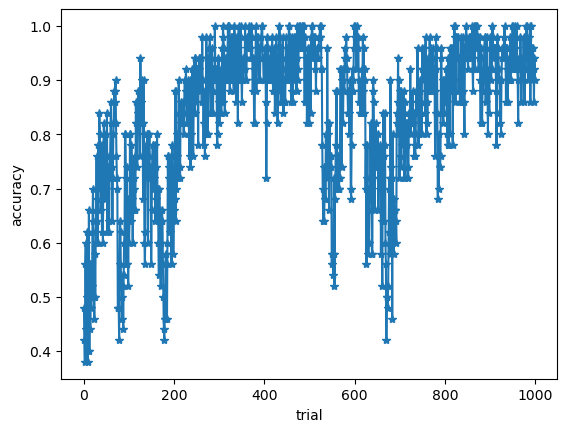

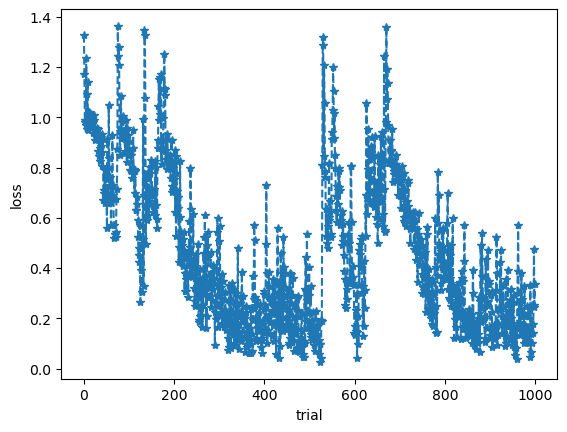

In [13]:
plt.figure()
plt.plot(epoch_acc, "-*")
plt.xlabel("trial")
plt.ylabel("accuracy")

epoch_loss = [epoch_loss[i].item() for i in range(len(epoch_loss))]
plt.figure()
plt.plot(epoch_loss, "--*")
plt.xlabel("trial")
plt.ylabel("loss")

r_final_arr.shape torch.Size([50000, 100, 750])


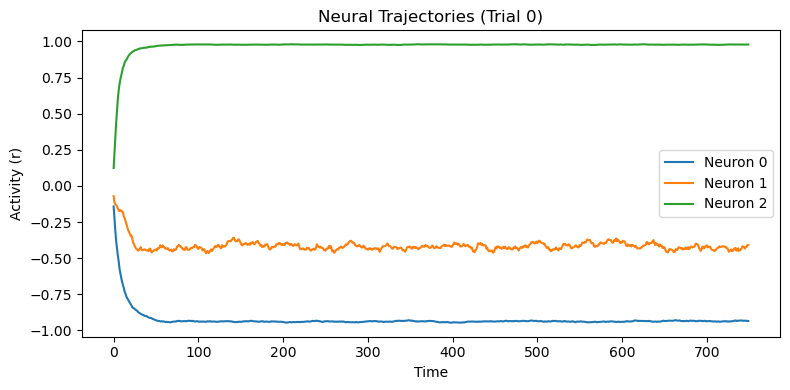

In [14]:
def plot_neural_trajectories(all_r, neuron_ids=[0,1,2], trial_id=0):
    r = all_r[trial_id,:,:].detach().cpu().numpy()  # shape (hidden, T)
    T = r.shape[1]

    plt.figure(figsize=(8,4))
    for nid in neuron_ids:
        plt.plot(range(T), r[nid,:], label=f"Neuron {nid}")
    
    plt.xlabel("Time")
    plt.ylabel("Activity (r)")
    plt.title(f"Neural Trajectories (Trial {trial_id})")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("r_final_arr.shape", r_final_arr.shape)
plot_neural_trajectories(r_final_arr)

In [15]:
y_ind0 = np.where(y == -1)[0]
y_ind1 = np.where(y == 1)[0]

context_ = 2*np.where(X[:,2:4,0] == 1)[1] - 1;
context_ind0 = np.where(context_==-1)[0]
context_ind1 = np.where(context_==1)[0]

motion_ = 2*np.array((X[:,0,0] > 0)).astype(int)-1
motion_ind0 = np.where(motion_==-1)[0]
motion_ind1 = np.where(motion_==1)[0]

color_ = 2*np.array((X[:,1,0] > 0)).astype(int)-1
color_ind0 = np.where(color_==-1)[0]
color_ind1 = np.where(color_==1)[0]

In [16]:
def plot_pca_trajectories(all_r, trial_ids=[0,1], labels=None):
    # all_r: (batch, hidden, T)
    all_r = all_r.detach().cpu().numpy()

    plt.figure(figsize=(8,6))

    for idx, trial in enumerate(trial_ids):
        r = all_r[trial,:,:]  # (hidden, T)
        pca = PCA(n_components=3)
        traj = pca.fit_transform(r.T)  # (T, 3)

        ax = plt.subplot(111, projection='3d')
        ax.plot(traj[:,0], traj[:,1], traj[:,2], label=f"Trial {trial}")

        if labels is not None:
            ax.set_title(labels[trial])

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    #ax.legend()
    plt.tight_layout()
    plt.show()

def plot_pca_trajectories_2d(all_r, trial_ids=[0,1], labels=None):
    # all_r: (batch, hidden, T)
    all_r = all_r.detach().cpu().numpy()

    plt.figure(figsize=(8,6))
    traj_avg = np.zeros((all_r.shape[2],2))
    
    for idx, trial in enumerate(trial_ids):
        r = all_r[trial,:,:]  # (hidden, T)
        pca = PCA(n_components=2)
        traj = pca.fit_transform(r.T)  # (T, 3)

        ax = plt.subplot(111)
        ax.plot(traj[:,0], traj[:,1], label=f"Trial {trial}")

        traj_avg += traj;
        if labels is not None:
            ax.set_title(labels[trial])

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    #ax.legend()
    plt.tight_layout()
    plt.show()

    return traj_avg/len(trial_ids)

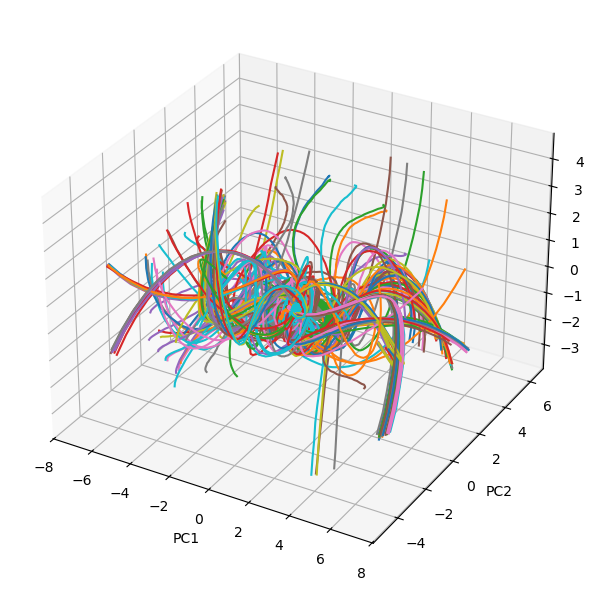

In [17]:
#list_of_trials = list(context_ind0[:100]) + list(context_ind1[:100])
list_of_trials = list(y_ind0[:100]) + list(y_ind1[:100]) #some trials choosing +1, some trials choosing -1
plot_pca_trajectories(all_r, trial_ids=list_of_trials)

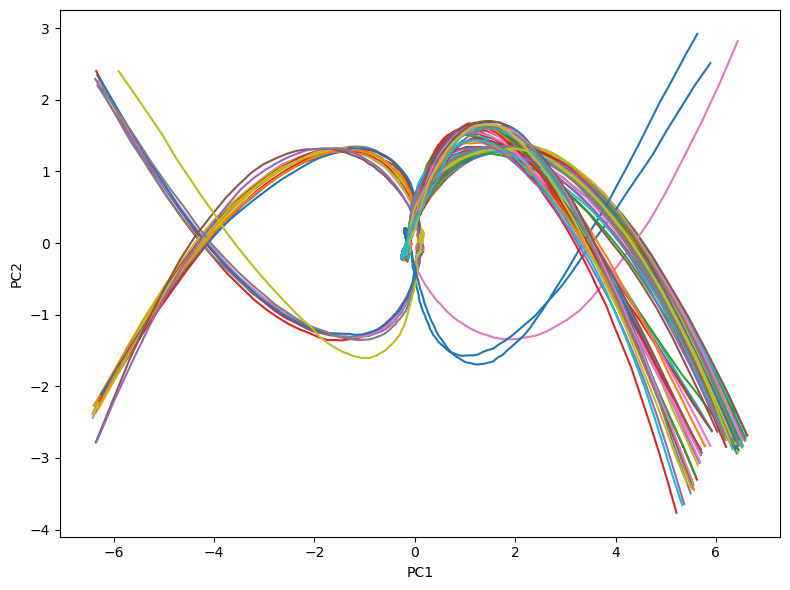

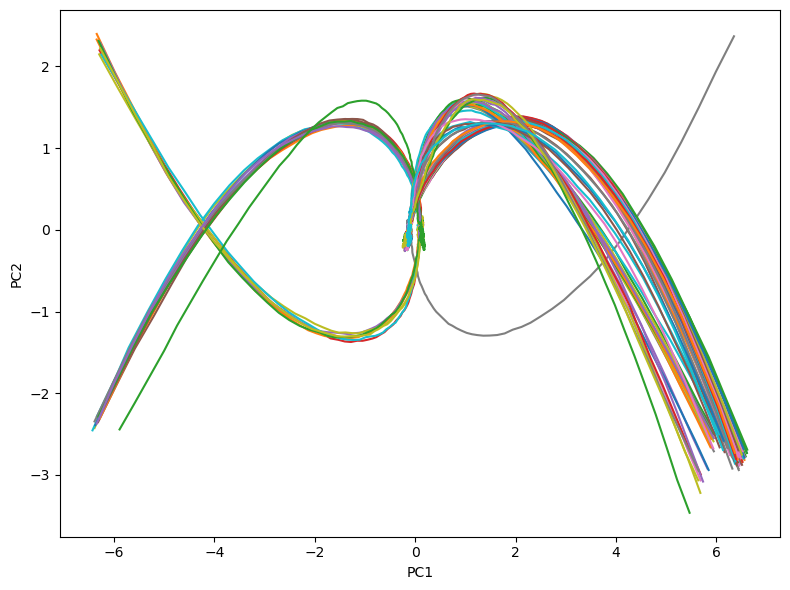

Text(0, 0.5, 'PC2')

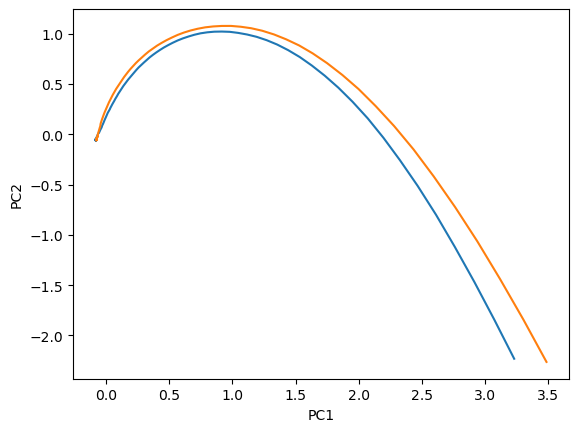

In [18]:
traj_avg1 = plot_pca_trajectories_2d(r_final_arr, trial_ids=y_ind0[:100])
traj_avg2 = plot_pca_trajectories_2d(r_final_arr, trial_ids=y_ind1[:100])

plt.plot(traj_avg1[:,0],traj_avg1[:,1]) 
plt.plot(traj_avg2[:,0],traj_avg2[:,1]) 
plt.xlabel("PC1")
plt.ylabel("PC2")

In [19]:
def compute_context_axis(all_r, X_input):
    """
    all_r: (batch, hidden, T)
    y_full: (batch, 3) -> (motion, color, context)
    """
    context = 2*np.where(X_input[:,2:3,0]==1)[0] - 1  # -1 or +1
    r = all_r.mean(dim=2)  # average over time (batch, hidden)

    r_ctx1 = r[context == 1].mean(dim=0)
    r_ctxm1 = r[context == -1].mean(dim=0)

    context_axis = r_ctx1 - r_ctxm1  # vector in hidden space
    context_axis = context_axis / context_axis.norm()

    return context_axis

In [20]:
def compute_choice_axes(model, all_r, y):
    
    # model.fc_out.weight: (1, hidden)
    choice_axis_model = model.fc_out.weight.data.squeeze(0)          # torch (H,)
    choice_axis_model = choice_axis_model / choice_axis_model.norm()

    # regression-based choice axis (fit final choice using population at final time)
    with torch.no_grad():
        R_final = all_r[:, :, -1].detach().cpu().numpy()   # (B, H)
        y_np = y.reshape(-1, 1)              # (B,1)
    # ridge to get direction in H space: solve R_final @ w = y
    ridge = Ridge(alpha=1.0, fit_intercept=False)
    ridge.fit(R_final, y_np)
    w = ridge.coef_.reshape(-1)    # shape (H,)
    w = w / np.linalg.norm(w)
    choice_axis_ridge = torch.from_numpy(w).float()

    return choice_axis_model.detach(), choice_axis_ridge


In [21]:
def project_and_summary(all_r, axis, y=None):
    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()
    axis = axis.to(all_r.device)
    
    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer
    proj = torch.einsum('bht,h->bt', all_r, axis)
    
    proj_np = proj.detach().cpu().numpy()

    print("proj_np.shape", proj_np.shape)
    #separate projectiom across trials for choice +1/-1, and take mean/std of projections
    mean_plus = proj_np[(y==1).cpu().numpy(),:].mean(axis=0) if y is not None else None
    mean_minus= proj_np[(y==-1).cpu().numpy(),:].mean(axis=0) if y is not None else None
    sem_plus  = proj_np[(y==1).cpu().numpy(),:].std(axis=0, ddof=1) / np.sqrt((y==1).sum().item()) if y is not None else None
    sem_minus = proj_np[(y==-1).cpu().numpy(),:].std(axis=0, ddof=1) / np.sqrt((y==-1).sum().item()) if y is not None else None

    T = mean_plus.shape[0]
    t = np.arange(T)
    plt.figure(figsize=(7,4))
    
    ind0 = np.where((y==-1).cpu().numpy())[0]
    ind0 = ind0[np.random.choice(len(ind0),100)] #ind0[-100:]
    ind1 = np.where((y==1).cpu().numpy())[0]
    ind1 = ind1[np.random.choice(len(ind1),100)] #ind1[-100:]
    plt.plot(t, proj_np[ind0, :].T, color='blue', alpha=0.2)
    plt.plot(t, proj_np[ind1,:].T, color = 'orange', alpha=0.2)
    plt.xlabel("Time")
    plt.ylabel("Projection")
   
    plt.figure()
    plt.fill_between(t, mean_minus-sem_minus, mean_minus+sem_minus, alpha=0.5, color='C0')
    plt.plot(t, mean_minus, label='-1', color='C0')
    plt.fill_between(t, mean_plus-sem_plus, mean_plus+sem_plus, alpha=0.5, color='C1')
    plt.plot(t, mean_plus, label='+1', color='C1')
    plt.xlabel('Time')
    plt.ylabel('Projection')
    plt.title('Projection over time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return proj_np

proj_np.shape (1000, 750)


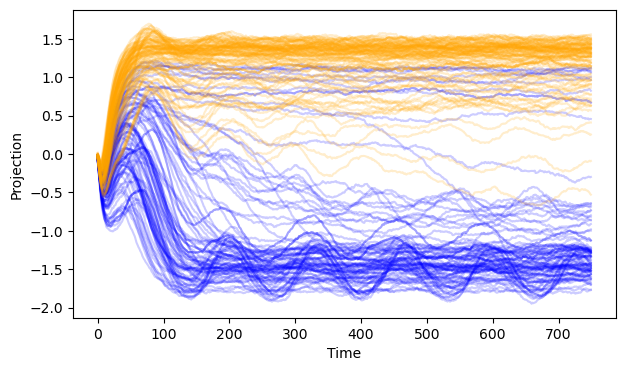

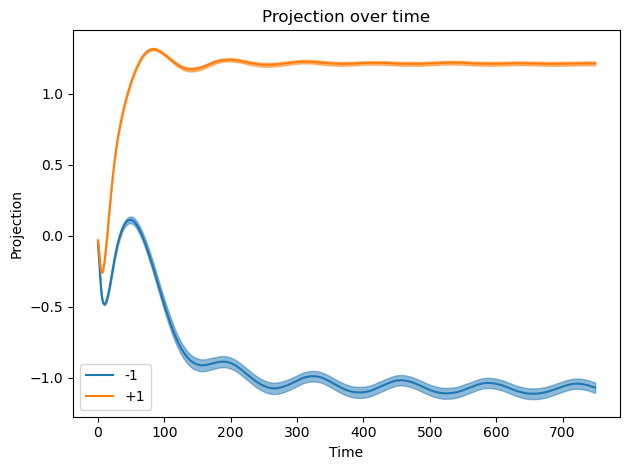

In [22]:
choice_axis_model, choice_axis_ridge = compute_choice_axes(model, all_r, y)
#context_axis = compute_context_axis(r_final_arr, X_arr)
proj_np = project_and_summary(all_r, choice_axis_model, y)

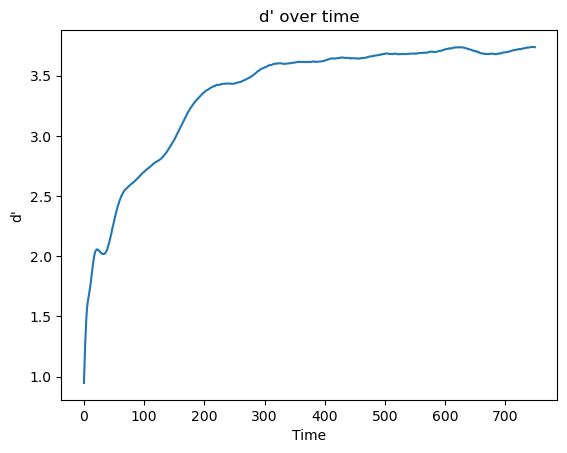

In [23]:
def compute_dprime_over_time(proj, y):
    # proj: (B, T)
    mu_p = proj[y==1].mean(axis=0)
    mu_m = proj[y==-1].mean(axis=0)
    var_p = proj[y==1].var(axis=0, ddof=1)
    var_m = proj[y==-1].var(axis=0, ddof=1)
    # pooled sd
    sd_pooled = np.sqrt(0.5*(var_p + var_m))
    dprime = (mu_p - mu_m) / (sd_pooled + 1e-10)
    return dprime

# --- 5) PCA on trial-averaged conditions and plotting 3D ---------------------

def trial_average_by_condition(all_r, y_dataset_full):
    # y_full[:,0]=motion,[:,1]=color,[:,2]=context
    motion = y_full[:,0].cpu().numpy()
    color  = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    conds = {}
    for m in [-1,1]:
        for c in [-1,1]:
            for ctx in [-1,1]:
                mask = (motion==m) & (color==c) & (context==ctx)
                if mask.sum() == 0:
                    continue
                # average over trials for that condition
                avg = all_r[mask].mean(dim=0).cpu().numpy()   # (H, T)
                conds[(m,c,ctx)] = avg
    return conds

dprime = compute_dprime_over_time(proj_np, y.cpu())
plt.figure(); plt.plot(dprime); plt.xlabel('Time'); plt.ylabel("d'"); plt.title("d' over time"); plt.show()


In [24]:
def trial_average_by_condition(all_r, y_full):
    # y_full[:,0]=motion,[:,1]=color,[:,2]=context
    motion = y_full[:,0].cpu().numpy()
    color  = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    conds = {}
    for m in [-1,1]:
        for c in [-1,1]:
            for ctx in [-1,1]:
                mask = (motion==m) & (color==c) & (context==ctx)
                if mask.sum() == 0:
                    continue

                # average over trials for that condition
                avg = all_r[mask].mean(dim=0).cpu().detach().numpy()   # (H, T) #average trajectory over each condition
                conds[(m,c,ctx)] = avg
    return conds

def pca_plot_condition_trajectories(cond_trajs, n_components=3):
    # stack and fit PCA on concatenated time X conditions
    trajs = []
    keys = []
    for k,v in cond_trajs.items():
        # v: (H, T) -> transpose to (T, H)
        trajs.append(v.T)
        keys.append(k)
    big = np.concatenate(trajs, axis=0)   # (T*conds, H)
    pca = PCA(n_components=n_components)
    big_p = pca.fit_transform(big)        # (T*conds, n_components)

    # split back and plot
    idx = 0
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    for k,v in zip(keys, trajs):
        T = v.shape[0]
        seg = big_p[idx:idx+T]
        ctx = k[2]
        color = 'C0' if ctx==-1 else 'C1'
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color=color, alpha=0.9)
        idx += T
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    plt.title('Condition-averaged PCA trajectories')
    plt.show()

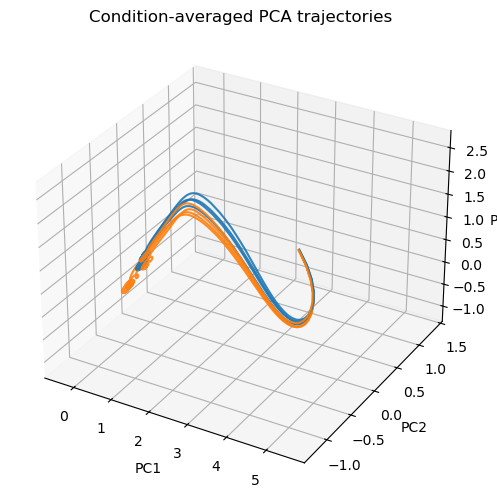

In [25]:
conds = trial_average_by_condition(all_r, y_dataset_full2)
pca_plot_condition_trajectories(conds)


In [ ]:
all_r.shape, len(y_dataset_full2)

In [ ]:
"""
# --- 6) endpoint scatter in 2D (PC1-PC2) -----------------------------------
def endpoint_scatter(R_pca, y_full):
    endpoints = R_pca[:, -1, :2]
    ctx = y_full[:,2].cpu().numpy()
    plt.figure(figsize=(6,5))
    plt.scatter(endpoints[ctx==-1,0], endpoints[ctx==-1,1], label='motion ctx', alpha=0.7)
    plt.scatter(endpoints[ctx== 1,0], endpoints[ctx== 1,1], label='color ctx', alpha=0.7)
    plt.legend()
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Endpoints (PC1-PC2)')
    plt.show()


B,H,T = r_final_arr[-10000:,:,:].shape
R_flat = r_final_arr[-10000:,:,:].cpu().detach().numpy().transpose(0,2,1).reshape(-1, H)
pca = PCA(n_components=3)
R_pca_flat = pca.fit_transform(R_flat)
R_pca = R_pca_flat.reshape(B, T, 3)
endpoint_scatter(R_pca, y_dataset_full)
"""

In [ ]:
#compute axes of motion, color, choice, and context like in the paper

In [26]:
def compute_betas(all_r, y_full):
    # all_r: (B, H, T)
    B, H, T = all_r.shape
    betas = np.zeros((T, H, 4))  # choice, motion, color, context

    choice  = y_full[:,0].cpu().numpy()
    motion  = y_full[:,1].cpu().numpy()
    color   = y_full[:,2].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    constant = torch.ones_like(y_full[:,0]).cpu().numpy()
    
    X = np.stack([choice, motion, color, context, constant], axis=1)

    for t in range(T):
        for h in range(H):
            y = all_r[:,h,t].cpu().detach().numpy()
            reg = LinearRegression().fit(X, y)
            betas[t,h,:] = reg.coef_[:4]

    return betas

def max_norm_axes(betas):
    # betas: (T, H, 4)
    axes = []
    for k in range(4):
        norms = np.linalg.norm(betas[:,:,k], axis=1)
        t_star = norms.argmax()
        axes.append(betas[t_star,:,k])
    return np.stack(axes)

betas = compute_betas(all_r, y_dataset_full2)
print("betas.shape", betas.shape)

beta_axes = max_norm_axes(betas)

Q, R = qr(beta_axes.T)
axes_orth = Q.T

betas.shape (750, 100, 4)


In [27]:
axes_orth.shape, all_r.shape

((4, 100), torch.Size([1000, 100, 750]))

In [28]:
def project_and_summary(all_r, axis, y=None, to_plot=[0,1], col=0, supress = False):
    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()
    axis = axis.to(all_r.device)
    
    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer

    print("all_r.shape", all_r.shape, axis.shape)
    print(np.transpose(axis, (1,0)).shape)

    #proj = torch.einsum('bht,h->bt', all_r, axis)
    r_btH = all_r.transpose(1, 2)   # [B, T, H]
    axis = axis.transpose(1,0)
    proj = torch.matmul(r_btH, axis)  # [B, T, 4]
    proj_np = proj.detach().cpu().numpy()

    #separate projectiom across trials for choice +1/-1, and take mean/std of projections
    mean_plus = proj_np[(y==1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    mean_minus= proj_np[(y==-1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    sem_plus  = proj_np[(y==1).cpu().numpy(),:,:].std(axis=0, ddof=1) / np.sqrt((y==1).sum().item()) if y is not None else None
    sem_minus = proj_np[(y==-1).cpu().numpy(),:,:].std(axis=0, ddof=1) / np.sqrt((y==-1).sum().item()) if y is not None else None

    T = mean_plus.shape[0]
    t = np.arange(T)
    plt.figure(figsize=(7,4))

    ind0 = np.where((y==-1).cpu().numpy())[0]
    ind1 = np.where((y==1).cpu().numpy())[0]

    axis_names = []
    if 0 in to_plot:
        axis_names.append("choice axis")
    if 1 in to_plot:
        axis_names.append("motion axis")
    if 2 in to_plot:
        axis_names.append("color axis")
    if 3 in to_plot:
        axis_names.append("context axis")

    plt.figure()
    if len(ind0) != 0:
        ind0 = ind0[np.random.choice(len(ind0),10)] #ind0[-100:]
        plt.plot(proj_np[ind0,:, to_plot[0]].T, proj_np[ind0, :, to_plot[1]].T, color = "C" + str(col))

    if len(ind1) != 0:
        ind1 = ind1[np.random.choice(len(ind1),10)] #ind1[-100:]
        plt.plot(proj_np[ind1,:, to_plot[0]].T, proj_np[ind1, :, to_plot[1]].T, color = "C" + str(col+1))
    plt.xlabel(axis_names[0])
    plt.ylabel(axis_names[1])

    if supress == False:
        plt.figure()
        print("mean_minus, sem_minus", mean_minus.shape, sem_minus.shape)
        plt.fill_between(t, mean_minus[:,0]-sem_minus[:,0], mean_minus[:,0]+sem_minus[:,0], alpha=0.5, color='C1')
        plt.plot(t, mean_minus[:,0], label='-1', color='C1')
        plt.fill_between(t, mean_plus[:,0]-sem_plus[:,0], mean_plus[:,0]+sem_plus[:,0], alpha=0.5, color='C0')
        plt.plot(t, mean_plus[:,0], label='+1', color='C0')
        plt.xlabel('Time')
        plt.ylabel('Projection')
        plt.title('Projection over time')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return proj_np

all_r.shape torch.Size([1000, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
mean_minus, sem_minus (750, 4) (750, 4)


<Figure size 700x400 with 0 Axes>

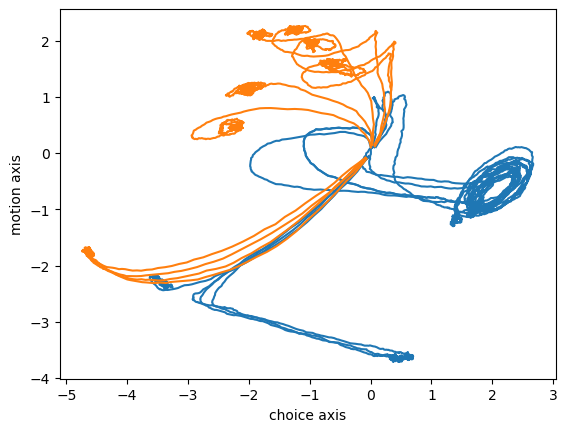

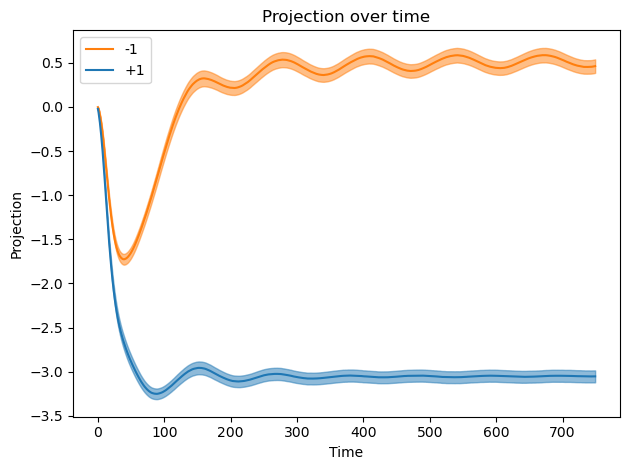

In [29]:
proj = project_and_summary(all_r, axes_orth, y)

all_r.shape torch.Size([520, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
all_r.shape torch.Size([520, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])


<Figure size 700x400 with 0 Axes>

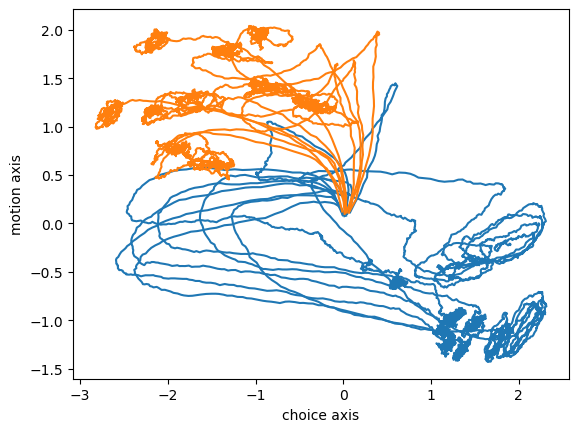

<Figure size 700x400 with 0 Axes>

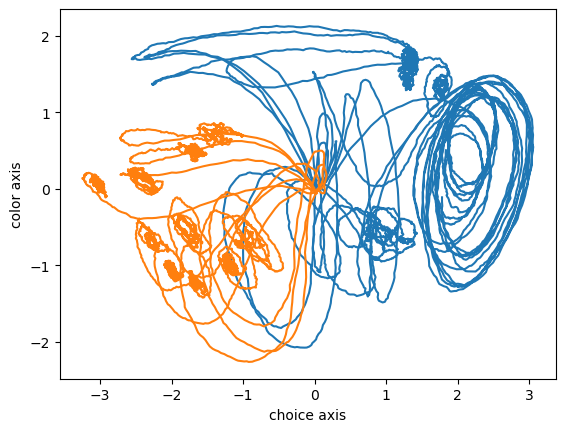

In [30]:
#look at dynamics, motion context
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], supress = True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], supress = True)



all_r.shape torch.Size([480, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
all_r.shape torch.Size([480, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])


<Figure size 700x400 with 0 Axes>

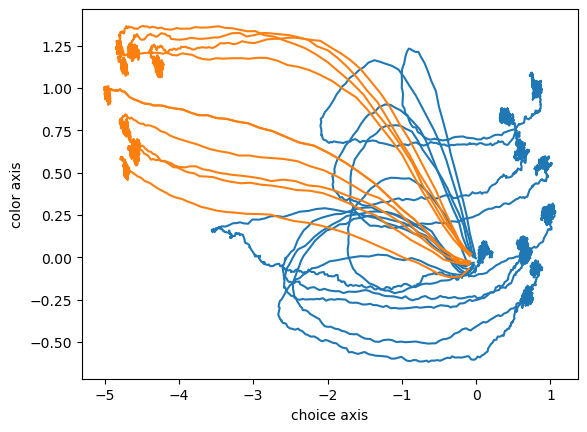

<Figure size 700x400 with 0 Axes>

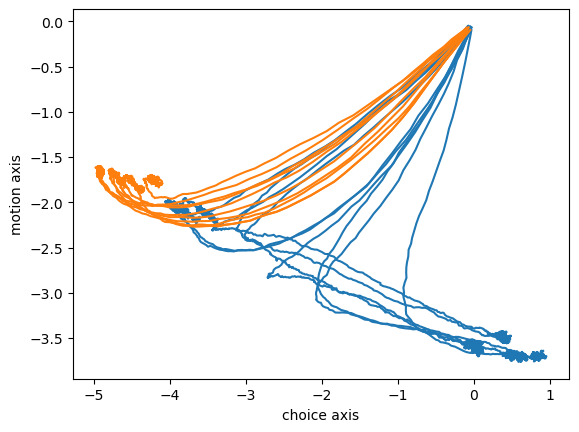

In [31]:
#look at dynamics, color context
ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], supress=True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,1], supress=True)
